In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.info()

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


In [4]:
df = df.drop_duplicates()

df = df.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

df['Geography'] = df['Geography'].str.strip()
df['Gender'] = df['Gender'].str.strip()

print(df['Geography'].unique())
print(df['Gender'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [5]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True,
    dtype=int
)

print(df.isnull().sum())
print(df.shape)
print(df.head())

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64
(10000, 12)
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         9382

In [6]:
print(df.describe())

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  \
count  10000.00000    10000.000000     10000.000000  10000.000000   
mean       0.70550        0.515100    100090.239881      0.203700   
std        0.45584        0.499797     57510.492818      0.4027

In [7]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,857 (85.38 KB)

 Trainable params: 21,217 (82.88 KB)

 Non-trainable params: 640 (2.50 KB)

In [11]:
opt = RMSprop(learning_rate=0.001)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'churn_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [13]:
hist = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    validation_split=0.1
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7347 - loss: 0.5414 - val_accuracy: 0.8313 - val_loss: 0.5048 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8075 - loss: 0.4409 - val_accuracy: 0.8425 - val_loss: 0.4253 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8261 - loss: 0.4142 - val_accuracy: 0.8562 - val_loss: 0.3794 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8374 - loss: 0.3928 - val_accuracy: 0.8475 - val_loss: 0.3515 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8414 - loss: 0.3831 - val_accuracy: 0.8650 - val_loss: 0.3346 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8418 - loss: 0.3800 - val_accuracy: 0.8650 - val_loss: 0.3246 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8508 - loss: 0.3695 - val_accuracy:

In [14]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Accuracy on test set:", test_acc)
print("Test loss:", test_loss)

63/63 - 0s - 2ms/step - accuracy: 0.8705 - loss: 0.3361
Accuracy on test set: 0.8705000281333923
Test loss: 0.33609020709991455


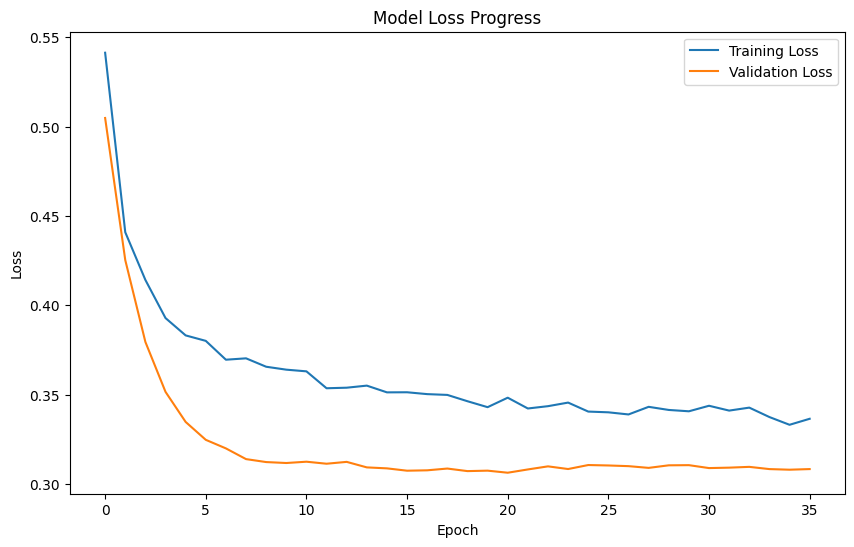

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

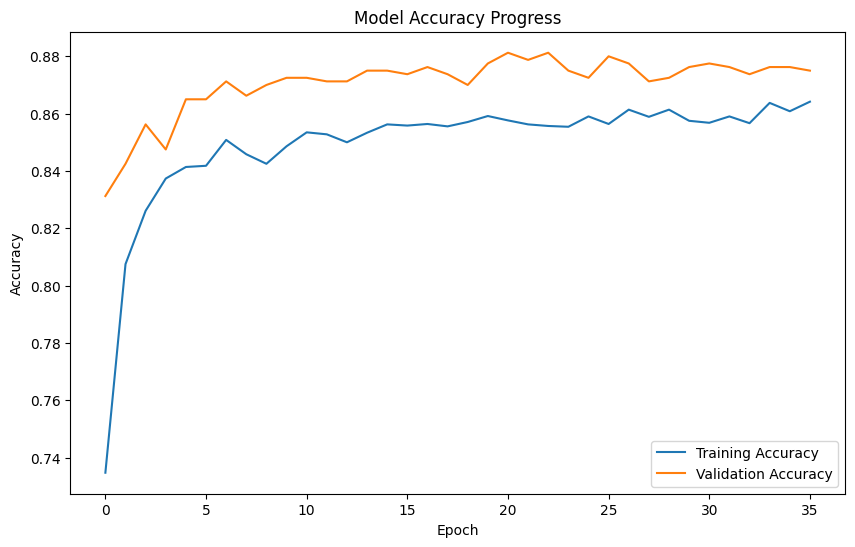

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [17]:
predictions = model.predict(X_test)

y_pred = (predictions >= 0.5).astype(int).ravel()

print("First 20 predictions:")
print(y_pred[:20])

print("First 20 true labels:")
print(y_test.values[:20])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 20 predictions:
[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
First 20 true labels:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]


In [18]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Stayed', 'Exited']
))

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
      Exited       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1544   49]
 [ 210  197]]


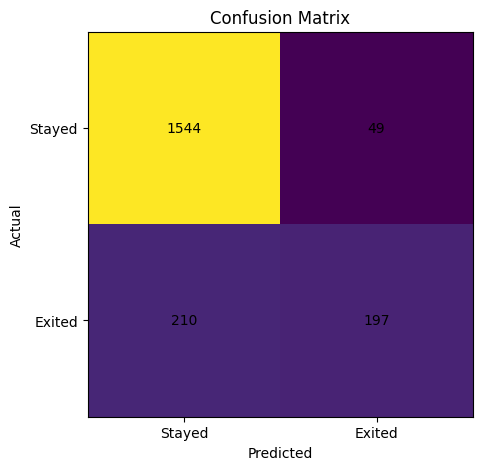

In [20]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0, 1], ['Stayed', 'Exited'])
plt.yticks([0, 1], ['Stayed', 'Exited'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [21]:
balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.7266349554485148
BER: 0.27336504455148525


In [22]:
tn, fp, fn, tp = cm.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

True Negative: 1544
False Positive: 49
False Negative: 210
True Positive: 197


In [23]:
model.save("churn_model.keras")

In [24]:
from tensorflow.keras.models import load_model

loaded_model = load_model("churn_model.keras")

test_loss, test_acc = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Loaded Model Accuracy:", test_acc)

63/63 - 0s - 7ms/step - accuracy: 0.8705 - loss: 0.3361
Loaded Model Accuracy: 0.8705000281333923
